<a href="https://colab.research.google.com/github/AvichalTrivedi7/IIT-Roorkee_InternshipWork/blob/main/Module_4_(Exercise_4_1)_IITR_Internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#  Imports and Data

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import umap

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

# [0,1] range — VAE uses sigmoid decoder and BCE loss
transform = transforms.ToTensor()

train_data = datasets.MNIST(root='./data', train=True,
                             download=True, transform=transform)
train_data = Subset(train_data, range(10000))
train_loader = DataLoader(train_data, batch_size=128,
                          shuffle=True, num_workers=0)

test_data = datasets.MNIST(root='./data', train=False,
                            download=True, transform=transform)
test_data_full = Subset(test_data, range(2000))
test_loader = DataLoader(test_data_full, batch_size=128,
                         shuffle=False, num_workers=0)

Using: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 504kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.41MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.23MB/s]


In [2]:
# VAE Architecture

class VAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder — maps image to μ and log σ²
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU()
        )
        self.fc_mu     = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        # Decoder — maps z back to image
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Sigmoid()   # output in [0,1] to match input range
        )

    def encode(self, x):
        h      = self.encoder(x)
        mu     = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std       # z = μ + σ·ε

    def decode(self, z):
        return self.decoder(z).view(-1, 1, 28, 28)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z          = self.reparameterise(mu, logvar)
        recon      = self.decode(z)
        return recon, mu, logvar


def vae_loss(recon, x, mu, logvar):
    # Reconstruction: BCE summed over pixels
    recon_loss = F.binary_cross_entropy(
        recon, x, reduction='sum')

    # KL divergence: closed form for N(μ,σ²) vs N(0,I)
    # KL = -0.5 * Σ(1 + log σ² - μ² - σ²)
    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + kl_loss, recon_loss, kl_loss

In [3]:
# Train VAE

def train_vae(model, loader, epochs=10):
    model     = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(epochs):
        total_loss  = 0
        total_recon = 0
        total_kl    = 0

        for imgs, _ in loader:
            imgs = imgs.to(device)

            recon, mu, logvar  = model(imgs)
            loss, recon_l, kl_l = vae_loss(recon, imgs, mu, logvar)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss  += loss.item()
            total_recon += recon_l.item()
            total_kl    += kl_l.item()

        n = len(loader.dataset)
        print(f"Epoch {epoch+1}/{epochs} "
              f"— Total: {total_loss/n:.4f} "
              f"| Recon: {total_recon/n:.4f} "
              f"| KL: {total_kl/n:.4f}")

    return model


print("Training VAE...")
vae = train_vae(VAE(latent_dim=16), train_loader, epochs=10)
print("Done.")

Training VAE...
Epoch 1/10 — Total: 232.5633 | Recon: 230.2719 | KL: 2.2914
Epoch 2/10 — Total: 190.4008 | Recon: 186.5310 | KL: 3.8698
Epoch 3/10 — Total: 172.0257 | Recon: 164.6698 | KL: 7.3560
Epoch 4/10 — Total: 154.3956 | Recon: 143.8834 | KL: 10.5122
Epoch 5/10 — Total: 143.9210 | Recon: 131.6946 | KL: 12.2264
Epoch 6/10 — Total: 136.0747 | Recon: 122.4864 | KL: 13.5883
Epoch 7/10 — Total: 131.1739 | Recon: 117.0051 | KL: 14.1688
Epoch 8/10 — Total: 127.9404 | Recon: 113.4037 | KL: 14.5368
Epoch 9/10 — Total: 125.2591 | Recon: 110.4090 | KL: 14.8500
Epoch 10/10 — Total: 122.5308 | Recon: 107.3092 | KL: 15.2216
Done.


In [5]:
# CNN Architecture and Training

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),              # 28→14
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),              # 14→7
        )
        self.penultimate = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU()
        )
        self.classifier = nn.Linear(128, 10)

    def forward(self, x):
        h      = self.features(x)
        h_pen  = self.penultimate(h)        # 128-dim penultimate
        logits = self.classifier(h_pen)
        return logits, h_pen                # return both


def train_cnn(model, loader, epochs=5):
    model     = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        total_loss = 0
        correct    = 0
        total      = 0

        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits, _    = model(imgs)
            loss         = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += labels.size(0)

        print(f"Epoch {epoch+1}/{epochs} "
              f"— Loss: {total_loss/len(loader):.4f} "
              f"| Acc: {correct/total*100:.1f}%")

    return model


print("Training CNN...")
cnn = train_cnn(CNN(), train_loader, epochs=5)
print("Done.")

Training CNN...
Epoch 1/5 — Loss: 0.7691 | Acc: 75.9%
Epoch 2/5 — Loss: 0.2167 | Acc: 94.0%
Epoch 3/5 — Loss: 0.1310 | Acc: 96.2%
Epoch 4/5 — Loss: 0.0926 | Acc: 97.3%
Epoch 5/5 — Loss: 0.0714 | Acc: 97.8%
Done.


In [6]:
# Extract All Representations

def extract_representations(vae, cnn, loader):
    vae.eval(); cnn.eval()

    vae_mus    = []   # μ from VAE encoder — deterministic representation
    cnn_feats  = []   # CNN penultimate layer features
    raw_pixels = []   # flattened raw pixels
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)

            # VAE: use μ not sampled z — μ is the deterministic rep
            mu, _  = vae.encode(imgs)
            vae_mus.append(mu.cpu().numpy())

            # CNN penultimate
            _, h_pen = cnn(imgs)
            cnn_feats.append(h_pen.cpu().numpy())

            # Raw pixels — just flatten
            raw_pixels.append(imgs.view(imgs.size(0), -1).cpu().numpy())

            all_labels.append(labels.numpy())

    return (np.concatenate(vae_mus),
            np.concatenate(cnn_feats),
            np.concatenate(raw_pixels),
            np.concatenate(all_labels))


# Extract from both train and test
print("Extracting train representations...")
train_vae, train_cnn, train_pix, train_labels = \
    extract_representations(vae, cnn, train_loader)

print("Extracting test representations...")
test_vae, test_cnn, test_pix, test_labels = \
    extract_representations(vae, cnn, test_loader)

print(f"VAE latents shape:    {train_vae.shape}")
print(f"CNN features shape:   {train_cnn.shape}")
print(f"Raw pixels shape:     {train_pix.shape}")

Extracting train representations...
Extracting test representations...
VAE latents shape:    (10000, 16)
CNN features shape:   (10000, 128)
Raw pixels shape:     (10000, 784)


In [7]:
# Three Linear Probes

def linear_probe(train_feats, test_feats,
                 train_labels, test_labels, name):
    # Standardise — important for logistic regression
    scaler      = StandardScaler()
    train_sc    = scaler.fit_transform(train_feats)
    test_sc     = scaler.transform(test_feats)

    clf = LogisticRegression(
        max_iter=1000,
        random_state=42,
        C=1.0
    )
    clf.fit(train_sc, train_labels)
    acc = clf.score(test_sc, test_labels) * 100

    print(f"{name:<30} Accuracy: {acc:.2f}%")
    return acc


print("Running linear probes...\n")

acc_vae = linear_probe(
    train_vae, test_vae,
    train_labels, test_labels,
    "VAE latents (μ)")

acc_cnn = linear_probe(
    train_cnn, test_cnn,
    train_labels, test_labels,
    "CNN penultimate layer")

acc_pix = linear_probe(
    train_pix, test_pix,
    train_labels, test_labels,
    "Raw pixels (flattened)")

print(f"\nRanking:")
print(f"  1. CNN:        {acc_cnn:.2f}%")
print(f"  2. VAE:        {acc_vae:.2f}%")
print(f"  3. Raw pixels: {acc_pix:.2f}%")

Running linear probes...

VAE latents (μ)                Accuracy: 86.35%
CNN penultimate layer          Accuracy: 97.45%
Raw pixels (flattened)         Accuracy: 85.90%

Ranking:
  1. CNN:        97.45%
  2. VAE:        86.35%
  3. Raw pixels: 85.90%


Computing UMAP (this takes ~1 min)...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


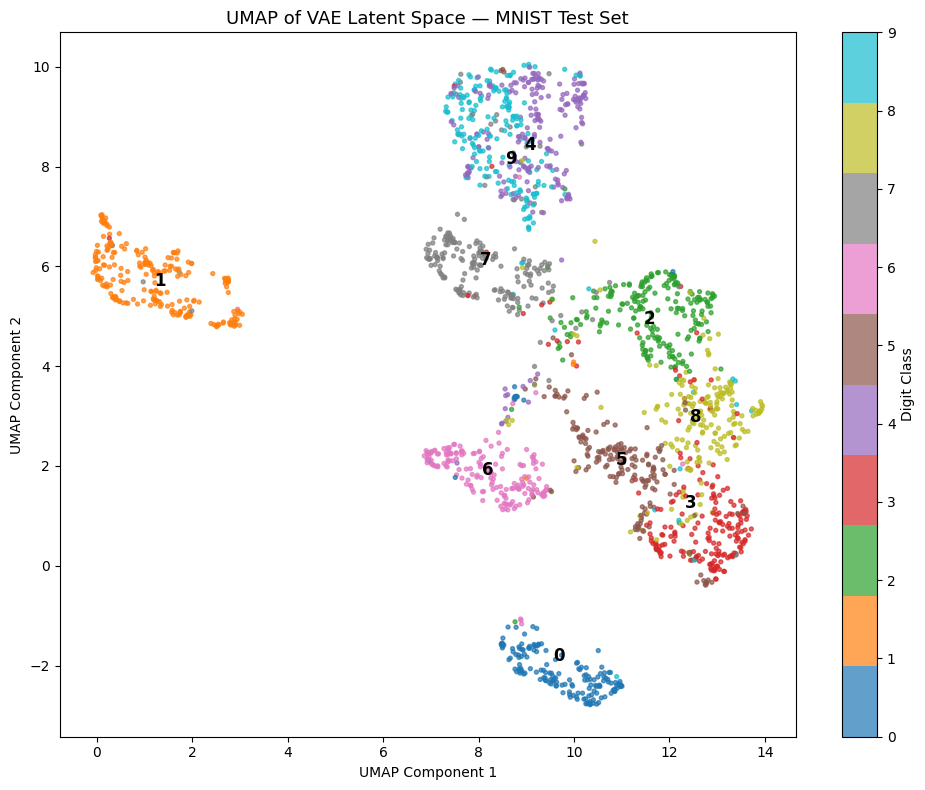

In [8]:
# UMAP Visualization

print("Computing UMAP (this takes ~1 min)...")

reducer   = umap.UMAP(n_components=2,
                       random_state=42,
                       n_neighbors=15,
                       min_dist=0.1)
emb_2d    = reducer.fit_transform(test_vae)

fig, ax   = plt.subplots(figsize=(10, 8))
scatter   = ax.scatter(
    emb_2d[:, 0], emb_2d[:, 1],
    c=test_labels,
    cmap='tab10',
    s=8,
    alpha=0.7
)

# Label each cluster
for digit in range(10):
    mask   = test_labels == digit
    centre = emb_2d[mask].mean(axis=0)
    ax.annotate(str(digit), centre,
                fontsize=12, fontweight='bold',
                ha='center', va='center')

plt.colorbar(scatter, ax=ax,
             label='Digit Class',
             ticks=range(10))
ax.set_title('UMAP of VAE Latent Space — MNIST Test Set',
             fontsize=13)
ax.set_xlabel('UMAP Component 1')
ax.set_ylabel('UMAP Component 2')
plt.tight_layout()
plt.savefig('umap_4_1.png', dpi=150)
plt.show()

# Interpretation And Observation

#### The three linear probe accuracies — CNN at 97.45%, VAE latents at 86.35%, and raw pixels at 85.90% — reveal that the VAE has compressed 784 pixel values into a 16-dimensional latent space while retaining almost identical class-separability to the full raw image, with only a 0.45% gap despite 49× compression. The CNN's large advantage is expected and not a criticism of the VAE — it was discriminatively trained with class labels as its direct objective, meaning every gradient update explicitly sharpened class boundaries, while the VAE never received a single label and organised its latent space purely as a side effect of learning to reconstruct faithfully. The UMAP confirms this emergent organisation — ten well-separated clusters appear with no label supervision, and visually similar digits sit geometrically close to each other (4 near 9, 3 near 5 and 8, 1 fully isolated) because the VAE encoded visual reconstruction similarity rather than class identity, and the two happen to align. The continuity of the latent space — enforced by the KL divergence term pulling all encodings toward N(0,I) — is what makes this organisation usable rather than just observable: every point between clusters decodes to a meaningful image, which means the space supports interpolation, sampling, and crucially, diffusion. This is directly why LDAE uses a KL-regularised VAE as its compression stage — the diffusion model must add and remove noise along trajectories through latent space, and the KL term is the architectural guarantee that those trajectories never pass through empty incoherent regions.

### The VAE is doing three things simultaneously that all reinforce each other:
Reconstruction loss → learn to encode and decode faithfully

KL loss             → keep the latent space smooth and continuous

Reparameterisation  → make the randomness differentiable so
                      gradients can flow through the sampling step